In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("/content/archive (17).zip")   # change path if needed

print(df.head())
print(df.info())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Locat

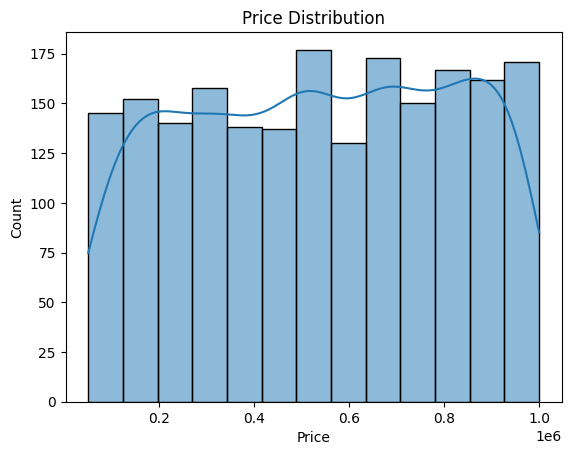

In [4]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

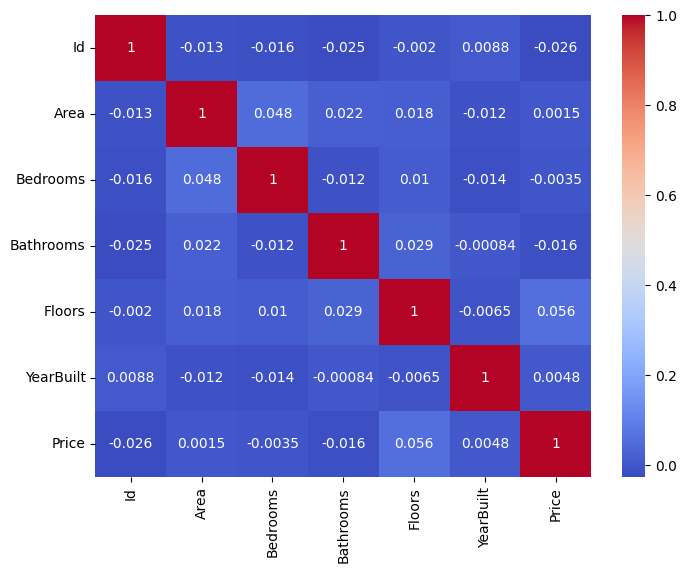

In [5]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [7]:
df["Price"] = np.log1p(df["Price"])

In [8]:
df["HouseAge"] = 2024 - df["YearBuilt"]

In [10]:
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "HouseAge"
]

X = df[features]
y = df["Price"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [14]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [15]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [16]:
def evaluate_model(y_true, y_pred, name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Results")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print("---------------------")

In [17]:
evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, ridge_pred, "Ridge Regression")
evaluate_model(y_test, lasso_pred, "Lasso Regression")
evaluate_model(y_test, xgb_pred, "XGBoost")

Linear Regression Results
RMSE: 0.751010524193734
MAE : 0.602166313726659
R2  : -0.010206173890008774
---------------------
Ridge Regression Results
RMSE: 0.7510070756318306
MAE : 0.602164612712081
R2  : -0.01019689638878818
---------------------
Lasso Regression Results
RMSE: 0.7508438252491298
MAE : 0.6020783890685434
R2  : -0.00975776043105192
---------------------
XGBoost Results
RMSE: 0.7673995575415872
MAE : 0.6128828147267783
R2  : -0.054777996150471076
---------------------


In [18]:
estimators = [
    ('ridge', Ridge(alpha=1.0)),
    ('lasso', Lasso(alpha=0.001)),
    ('xgb', XGBRegressor(n_estimators=300))
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

evaluate_model(y_test, stack_pred, "Stacking Model")

Stacking Model Results
RMSE: 0.7511405667761145
MAE : 0.6005273176488537
R2  : -0.010556052324853349
---------------------


In [19]:
final_predictions = np.expm1(stack_pred)